# Supply Chain Network Design — Olist Dataset
## Phase 2: Demand Forecasting

**Goal**: Forecast monthly order demand per Brazilian state using three models:
- **SARIMA** — classical statistical baseline
- **Prophet** — Facebook's robust trend/seasonality model
- **LightGBM** — gradient boosting with lag & calendar features

**Output**: Probabilistic 3-month forecasts per state → fed into Phase 3 (MILP optimization)

---
**Prerequisites**: Run `phase1_data_engineering.py` first to generate `outputs/monthly_demand.csv`

## 0. Imports & Configuration

In [ ]:
# Install dependencies if needed
# !pip install prophet lightgbm scikit-learn statsmodels matplotlib seaborn pandas numpy

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Paths ──────────────────────────────────────────────────────────────
OUTPUT_DIR  = "C:\M2 SPA\Supply Chain\outputs"
FORECAST_HORIZON = 3          # months ahead to forecast
FOCUS_STATES = ["SP", "RJ", "MG", "BA", "RS"]  # states to visualize in detail

print("✅ Imports OK")

✅ Imports OK


## 1. Load & Prepare Monthly Demand Data

In [4]:
# Load monthly demand (output from Phase 1)
monthly = pd.read_csv(f"{OUTPUT_DIR}/monthly_demand.csv", parse_dates=["order_month"])
monthly.sort_values(["demand_state", "order_month"], inplace=True)
monthly.reset_index(drop=True, inplace=True)

print(f"Shape        : {monthly.shape}")
print(f"Date range   : {monthly['order_month'].min().date()} → {monthly['order_month'].max().date()}")
print(f"States       : {monthly['demand_state'].nunique()}")
print(f"\nSample:")
monthly.head(8)

Shape        : (556, 6)
Date range   : 2016-09-01 → 2018-08-01
States       : 27

Sample:


,order_month,demand_state,orders,items,revenue,freight
0,2017-01-01,AC,2,4,723.14,133.54
1,2017-02-01,AC,3,6,597.40,147.00
2,2017-03-01,AC,2,2,530.18,74.19
3,2017-04-01,AC,5,5,1351.51,189.13
4,2017-05-01,AC,8,8,2371.73,277.34
5,2017-06-01,AC,4,4,510.27,124.49
6,2017-07-01,AC,5,5,794.40,175.71
7,2017-08-01,AC,4,4,765.83,127.90


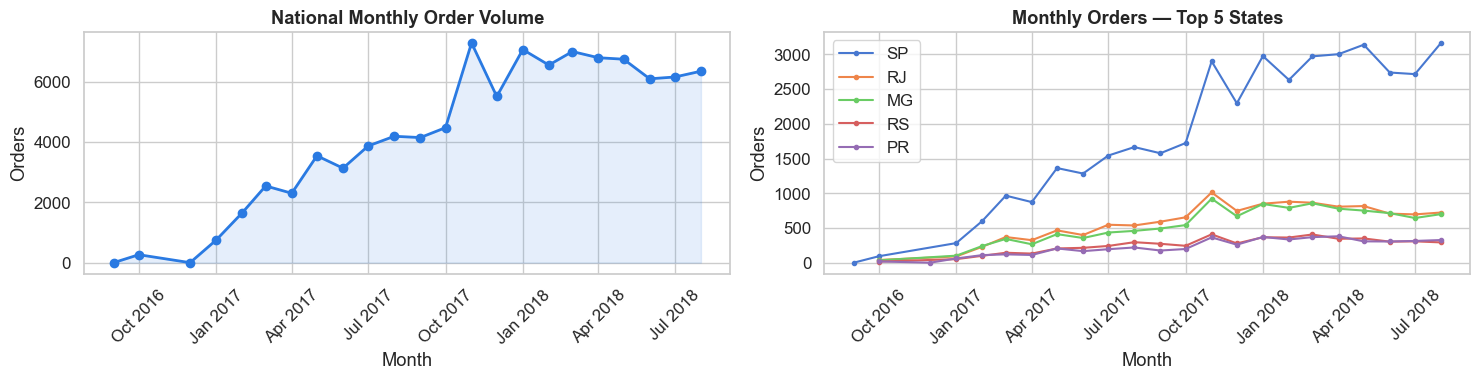

✅ Saved: 08_monthly_demand_overview.png


In [5]:
# ── National aggregate time series ─────────────────────────────────────
national = (
    monthly.groupby("order_month")[["orders", "items", "revenue"]]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(national["order_month"], national["orders"], marker="o",
             linewidth=2, color="#2a7ae2")
axes[0].fill_between(national["order_month"], national["orders"],
                     alpha=0.12, color="#2a7ae2")
axes[0].set_title("National Monthly Order Volume", fontweight="bold")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Orders")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].tick_params(axis="x", rotation=45)

# Top 5 states
top5 = monthly.groupby("demand_state")["orders"].sum().nlargest(5).index.tolist()
for state in top5:
    s = monthly[monthly["demand_state"] == state]
    axes[1].plot(s["order_month"], s["orders"], marker=".", linewidth=1.5, label=state)
axes[1].set_title("Monthly Orders — Top 5 States", fontweight="bold")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Orders")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_monthly_demand_overview.png", dpi=150)
plt.show()
print("✅ Saved: 08_monthly_demand_overview.png")

## 2. Stationarity Tests (ADF)

In [6]:
def adf_test(series, name=""):
    """Run Augmented Dickey-Fuller test and return result dict."""
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "State"       : name,
        "ADF Stat"    : round(result[0], 4),
        "p-value"     : round(result[1], 4),
        "Stationary"  : "✅ Yes" if result[1] < 0.05 else "❌ No",
        "Crit Val 5%" : round(result[4]["5%"], 4),
    }

adf_results = []
for state in FOCUS_STATES:
    s = monthly[monthly["demand_state"] == state]["orders"]
    adf_results.append(adf_test(s, state))

# National series
adf_results.append(adf_test(national["orders"], "NATIONAL"))

pd.DataFrame(adf_results)

,State,ADF Stat,p-value,Stationary,Crit Val 5%
0,SP,-5.25,0.00,✅ Yes,-3.15
1,RJ,-2.19,0.21,❌ No,-3.02
2,MG,-2.33,0.16,❌ No,-3.03
3,BA,-3.58,0.01,✅ Yes,-3.03
4,RS,-2.82,0.06,❌ No,-3.03
5,NATIONAL,-1.79,0.38,❌ No,-3.01


ValueError: Can only compute partial correlations for lags up to 50% of the sample size. The requested nlags 12 must be < 11.

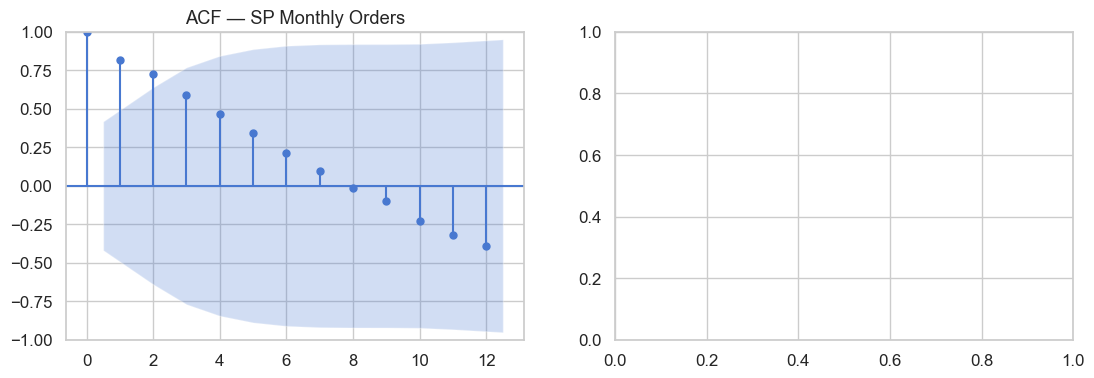

In [7]:
# ── ACF / PACF for SP (most important state) ───────────────────────────
sp_series = monthly[monthly["demand_state"] == "SP"]["orders"].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(sp_series,  lags=12, ax=axes[0], title="ACF — SP Monthly Orders")
plot_pacf(sp_series, lags=12, ax=axes[1], title="PACF — SP Monthly Orders", method="ywm")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/09_acf_pacf_SP.png", dpi=150)
plt.show()
print("ACF/PACF suggest p, d, q order for SARIMA below.")

## 3. Helper Functions

In [8]:
def train_test_split_ts(df, state, test_months=3):
    """Split a single state's time series into train / test."""
    s = (
        df[df["demand_state"] == state]
        .set_index("order_month")["orders"]
        .asfreq("MS")           # month-start frequency
        .fillna(0)
    )
    train = s.iloc[:-test_months]
    test  = s.iloc[-test_months:]
    return train, test


def evaluation_metrics(actual, predicted, model_name):
    """Return MAE, RMSE, MAPE for a forecast."""
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mape  = np.mean(np.abs((actual - predicted) / np.where(actual == 0, 1, actual))) * 100
    return {"Model": model_name, "MAE": round(mae,1), "RMSE": round(rmse,1), "MAPE%": round(mape,1)}


print("✅ Helper functions defined")

✅ Helper functions defined


## 4. Model 1 — SARIMA

In [9]:
def fit_sarima(train, order=(1,1,1), seasonal_order=(1,1,0,12)):
    """Fit SARIMA and return fitted model."""
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)


def forecast_sarima(fitted_model, steps, train_index):
    """Generate point forecast + 95% CI."""
    pred   = fitted_model.get_forecast(steps=steps)
    mean   = pred.predicted_mean
    ci     = pred.conf_int(alpha=0.05)
    return mean, ci


# ── Fit SARIMA for each focus state ────────────────────────────────────
sarima_results = {}

for state in FOCUS_STATES:
    train, test = train_test_split_ts(monthly, state)
    if len(train) < 10:
        print(f"  {state}: not enough data — skipping")
        continue
    fitted = fit_sarima(train)
    mean_fc, ci = forecast_sarima(fitted, steps=len(test), train_index=train.index)
    metrics = evaluation_metrics(test.values, mean_fc.values[:len(test)], "SARIMA")
    sarima_results[state] = {
        "train": train, "test": test,
        "forecast": mean_fc, "ci": ci,
        "fitted": fitted, "metrics": metrics
    }
    print(f"  {state} → MAPE: {metrics['MAPE%']:.1f}%  |  MAE: {metrics['MAE']:.0f}  |  RMSE: {metrics['RMSE']:.0f}")

print("\n✅ SARIMA fitting complete")

  SP → MAPE: 17.4%  |  MAE: 490  |  RMSE: 504
  RJ → MAPE: 10.6%  |  MAE: 76  |  RMSE: 102
  MG → MAPE: 17.1%  |  MAE: 115  |  RMSE: 131
  BA → MAPE: 30.9%  |  MAE: 53  |  RMSE: 68
  RS → MAPE: 59.7%  |  MAE: 179  |  RMSE: 185

✅ SARIMA fitting complete


Error generating SARIMA diagnostics for SP: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.


<Figure size 1300x700 with 0 Axes>

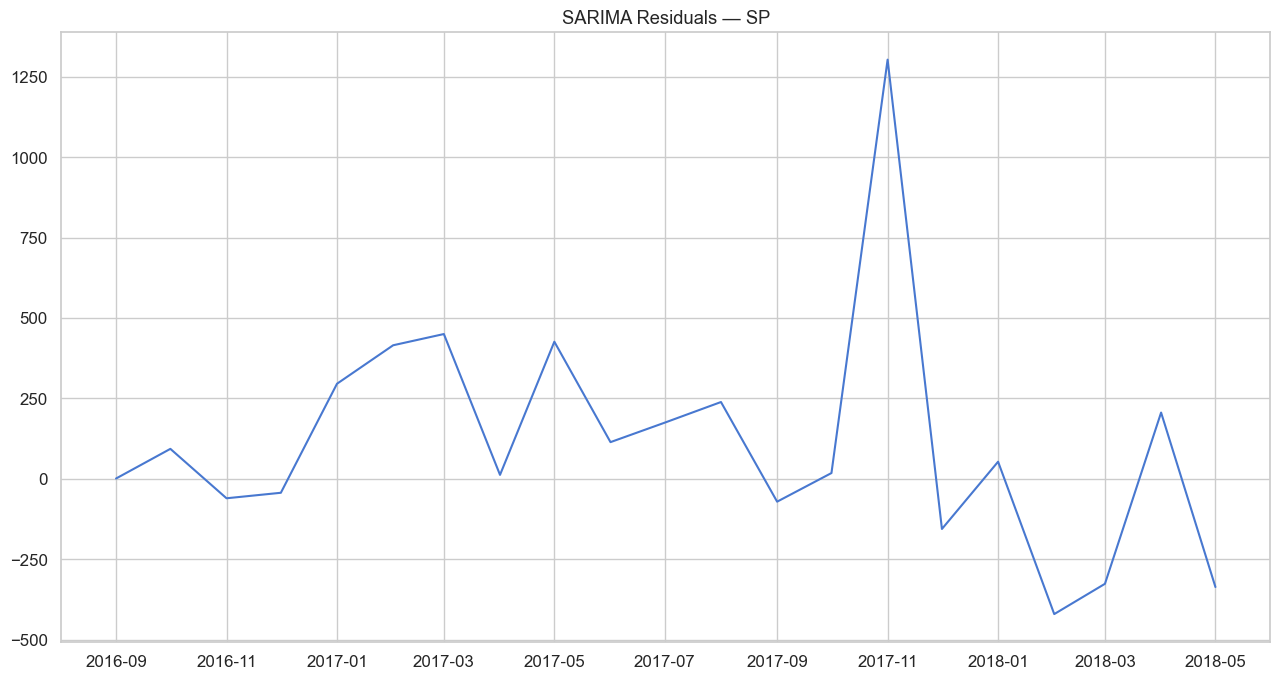

In [28]:
# ── SARIMA diagnostics for SP ───────────────────────────────────────────
if "SP" in sarima_results:
    try:
        # Check if we have enough data points for diagnostics
        if len(sarima_results["SP"]["fitted"].data.orig_endog) > sarima_results["SP"]["fitted"].model.k_ar:
            sarima_results["SP"]["fitted"].plot_diagnostics(figsize=(13, 7))
            plt.suptitle("SARIMA Diagnostics — SP", fontweight="bold", y=1.01)
            plt.tight_layout()
            plt.savefig(f"{OUTPUT_DIR}/10_sarima_diagnostics_SP.png", dpi=150)
            plt.show()
        else:
            print("Not enough data points for SP SARIMA diagnostics. Consider using a model with fewer lags or more data.")
    except Exception as e:
        print(f"Error generating SARIMA diagnostics for SP: {e}")
        # Alternative: Try with a simpler diagnostic approach
        plt.figure(figsize=(13, 7))
        plt.plot(sarima_results["SP"]["fitted"].resid)
        plt.title("SARIMA Residuals — SP")
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/10_sarima_diagnostics_SP.png", dpi=150)
        plt.show()

## 5. Model 2 — Prophet

In [11]:
def fit_prophet(train_series, yearly_seasonality=True):
    """Fit Prophet model. Expects a pd.Series with DatetimeIndex."""
    df_prophet = train_series.reset_index().rename(
        columns={"order_month": "ds", "orders": "y"}
    )
    df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])

    m = Prophet(
        yearly_seasonality=yearly_seasonality,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.95,
        changepoint_prior_scale=0.05,
    )
    m.fit(df_prophet)
    return m


def forecast_prophet(model, steps):
    """Generate Prophet forecast for `steps` months ahead."""
    future = model.make_future_dataframe(periods=steps, freq="MS")
    fc     = model.predict(future)
    return fc


# ── Fit Prophet for each focus state ───────────────────────────────────
prophet_results = {}

for state in FOCUS_STATES:
    train, test = train_test_split_ts(monthly, state)
    if len(train) < 10:
        continue

    train_df = train.reset_index().rename(columns={"order_month": "ds", 0: "y"})
    train_df.columns = ["ds", "y"]
    train_df["ds"] = pd.to_datetime(train_df["ds"])

    m      = fit_prophet(train)
    fc     = forecast_prophet(m, steps=len(test))
    fc_test = fc.tail(len(test))
    metrics = evaluation_metrics(test.values, fc_test["yhat"].values, "Prophet")

    prophet_results[state] = {
        "train": train, "test": test,
        "forecast": fc, "model": m, "metrics": metrics
    }
    print(f"  {state} → MAPE: {metrics['MAPE%']:.1f}%  |  MAE: {metrics['MAE']:.0f}  |  RMSE: {metrics['RMSE']:.0f}")

print("\n✅ Prophet fitting complete")

23:29:58 - cmdstanpy - INFO - Chain [1] start processing
23:30:21 - cmdstanpy - INFO - Chain [1] done processing


  SP → MAPE: 55.6%  |  MAE: 1535  |  RMSE: 1902


23:30:22 - cmdstanpy - INFO - Chain [1] start processing
23:30:27 - cmdstanpy - INFO - Chain [1] done processing
23:30:27 - cmdstanpy - INFO - Chain [1] start processing


  RJ → MAPE: 193.2%  |  MAE: 1380  |  RMSE: 1576


23:30:50 - cmdstanpy - INFO - Chain [1] done processing
23:30:50 - cmdstanpy - INFO - Chain [1] start processing


  MG → MAPE: 72.5%  |  MAE: 503  |  RMSE: 648


23:31:11 - cmdstanpy - INFO - Chain [1] done processing
23:31:11 - cmdstanpy - INFO - Chain [1] start processing


  BA → MAPE: 81.5%  |  MAE: 156  |  RMSE: 159


23:31:17 - cmdstanpy - INFO - Chain [1] done processing


  RS → MAPE: 108.0%  |  MAE: 328  |  RMSE: 437

✅ Prophet fitting complete


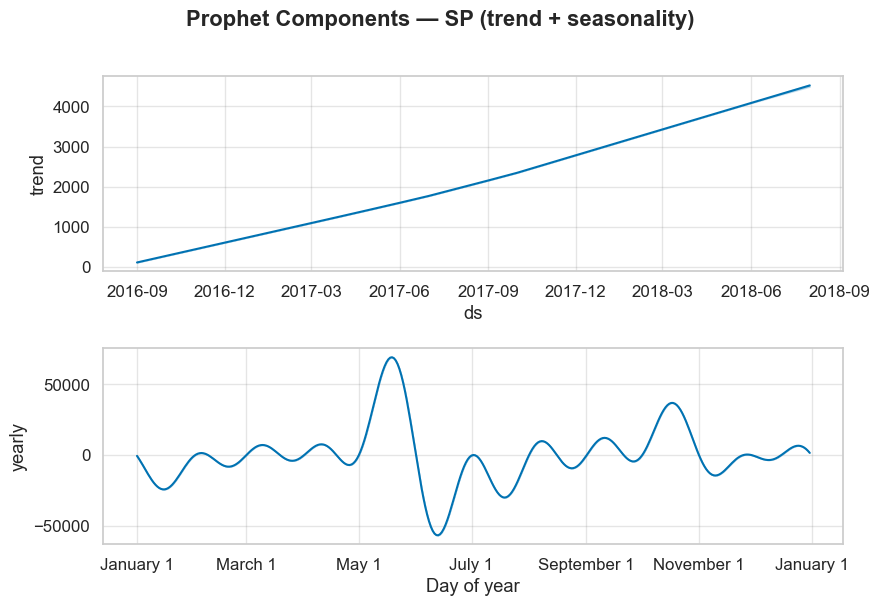

In [12]:
# ── Prophet components plot for SP ─────────────────────────────────────
if "SP" in prophet_results:
    fig = prophet_results["SP"]["model"].plot_components(
        prophet_results["SP"]["forecast"]
    )
    fig.suptitle("Prophet Components — SP (trend + seasonality)",
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/11_prophet_components_SP.png", dpi=150)
    plt.show()

## 6. Model 3 — LightGBM with Lag & Calendar Features

In [13]:
def make_lgbm_features(df_state, lags=[1, 2, 3, 6], rolling_windows=[2, 3]):
    """
    Build supervised ML features from a monthly time series.
    Each row = one month, features = lags + rolling stats + calendar.
    """
    df = df_state.copy().sort_values("order_month")
    df = df.set_index("order_month").asfreq("MS").fillna(0).reset_index()

    # Calendar features
    df["month"]      = df["order_month"].dt.month
    df["quarter"]    = df["order_month"].dt.quarter
    df["year"]       = df["order_month"].dt.year
    df["month_sin"]  = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"]  = np.cos(2 * np.pi * df["month"] / 12)

    # Lag features
    for lag in lags:
        df[f"lag_{lag}"] = df["orders"].shift(lag)

    # Rolling statistics
    for w in rolling_windows:
        df[f"roll_mean_{w}"] = df["orders"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["orders"].shift(1).rolling(w).std()

    df.dropna(inplace=True)
    return df


FEATURE_COLS = [
    "month", "quarter", "year", "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_6",
    "roll_mean_2", "roll_mean_3", "roll_std_2", "roll_std_3",
]

print("✅ LightGBM feature builder ready")

✅ LightGBM feature builder ready


In [15]:
def fit_lgbm(features_df, test_months=3):
    """Train LightGBM on all states combined (global model)."""
    df = features_df.copy()
    le = LabelEncoder()
    
    # Convert demand_state to string to ensure uniform data type
    df["demand_state"] = df["demand_state"].astype(str)
    df["state_enc"] = le.fit_transform(df["demand_state"])

    feature_cols_with_state = FEATURE_COLS + ["state_enc"]
    cutoff = df["order_month"].max() - pd.DateOffset(months=test_months)
    train  = df[df["order_month"] <= cutoff]
    test   = df[df["order_month"] >  cutoff]

    X_train, y_train = train[feature_cols_with_state], train["orders"]
    X_test,  y_test  = test[feature_cols_with_state],  test["orders"]

    params = {
        "objective"       : "regression",
        "metric"          : "mae",
        "n_estimators"    : 500,
        "learning_rate"   : 0.05,
        "num_leaves"      : 31,
        "min_child_samples": 5,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq"    : 5,
        "verbose"         : -1,
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)],
    )
    return model, le, train, test, feature_cols_with_state


# Build feature matrix across all states
all_features = []
for state in monthly["demand_state"].unique():
    s = monthly[monthly["demand_state"] == state][["order_month", "orders"]].copy()
    s["demand_state"] = state
    feat = make_lgbm_features(s)
    all_features.append(feat)

features_df = pd.concat(all_features, ignore_index=True)
print(f"Feature matrix shape: {features_df.shape}")

lgbm_model, le, lgbm_train, lgbm_test, feat_cols = fit_lgbm(features_df)
print(f"\nLightGBM trained on {len(lgbm_train):,} rows | Validated on {len(lgbm_test):,} rows")

Feature matrix shape: (439, 16)

LightGBM trained on 359 rows | Validated on 80 rows


In [16]:
# ── LightGBM evaluation per focus state ────────────────────────────────
lgbm_results = {}
print("LightGBM test-set performance per focus state:\n")

for state in FOCUS_STATES:
    test_state = lgbm_test[lgbm_test["demand_state"] == state]
    if test_state.empty:
        continue
    preds   = lgbm_model.predict(test_state[feat_cols])
    preds   = np.maximum(preds, 0)  # no negative orders
    metrics = evaluation_metrics(test_state["orders"].values, preds, "LightGBM")
    lgbm_results[state] = {"test": test_state, "preds": preds, "metrics": metrics}
    print(f"  {state} → MAPE: {metrics['MAPE%']:.1f}%  |  MAE: {metrics['MAE']:.0f}  |  RMSE: {metrics['RMSE']:.0f}")

print("\n✅ LightGBM evaluation complete")

LightGBM test-set performance per focus state:

  SP → MAPE: 6.1%  |  MAE: 184  |  RMSE: 232
  RJ → MAPE: 2.0%  |  MAE: 14  |  RMSE: 16
  MG → MAPE: 5.9%  |  MAE: 40  |  RMSE: 42
  BA → MAPE: 26.1%  |  MAE: 45  |  RMSE: 56
  RS → MAPE: 19.5%  |  MAE: 59  |  RMSE: 59

✅ LightGBM evaluation complete


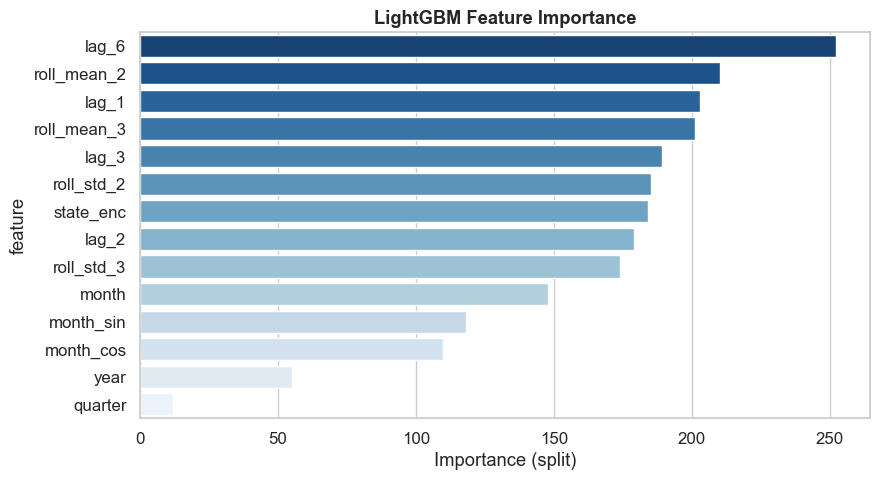

✅ Saved: 12_lgbm_feature_importance.png


In [17]:
# ── Feature importance ─────────────────────────────────────────────────
importance = pd.DataFrame({
    "feature"   : feat_cols,
    "importance": lgbm_model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=importance, x="importance", y="feature", palette="Blues_r", ax=ax)
ax.set_title("LightGBM Feature Importance", fontweight="bold")
ax.set_xlabel("Importance (split)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/12_lgbm_feature_importance.png", dpi=150)
plt.show()
print("✅ Saved: 12_lgbm_feature_importance.png")

## 7. Model Comparison

In [18]:
# Build comparison table across focus states and models
rows = []
for state in FOCUS_STATES:
    if state in sarima_results:
        r = sarima_results[state]["metrics"].copy()
        r["State"] = state
        rows.append(r)
    if state in prophet_results:
        r = prophet_results[state]["metrics"].copy()
        r["State"] = state
        rows.append(r)
    if state in lgbm_results:
        r = lgbm_results[state]["metrics"].copy()
        r["State"] = state
        rows.append(r)

comparison_df = (
    pd.DataFrame(rows)[["State", "Model", "MAE", "RMSE", "MAPE%"]]
    .sort_values(["State", "MAPE%"])
)
comparison_df

,State,Model,MAE,RMSE,MAPE%
11,BA,LightGBM,45.10,55.60,26.10
9,BA,SARIMA,53.00,68.20,30.90
10,BA,Prophet,156.40,158.70,81.50
8,MG,LightGBM,39.90,42.00,5.90
6,MG,SARIMA,115.10,130.90,17.10
7,MG,Prophet,503.20,647.90,72.50
5,RJ,LightGBM,14.00,15.90,2.00
3,RJ,SARIMA,76.50,102.40,10.60
4,RJ,Prophet,1379.90,1576.20,193.20
14,RS,LightGBM,58.90,59.30,19.50


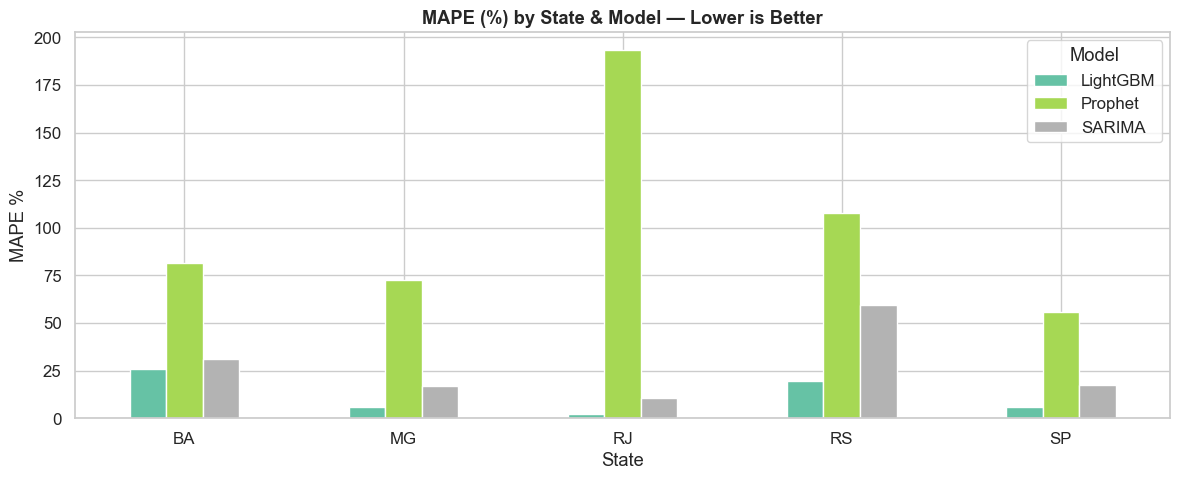

✅ Saved: 13_model_comparison_mape.png


In [19]:
# ── MAPE comparison bar chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
pivot = comparison_df.pivot(index="State", columns="Model", values="MAPE%")
pivot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
ax.set_title("MAPE (%) by State & Model — Lower is Better", fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel("MAPE %")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Model")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/13_model_comparison_mape.png", dpi=150)
plt.show()
print("✅ Saved: 13_model_comparison_mape.png")

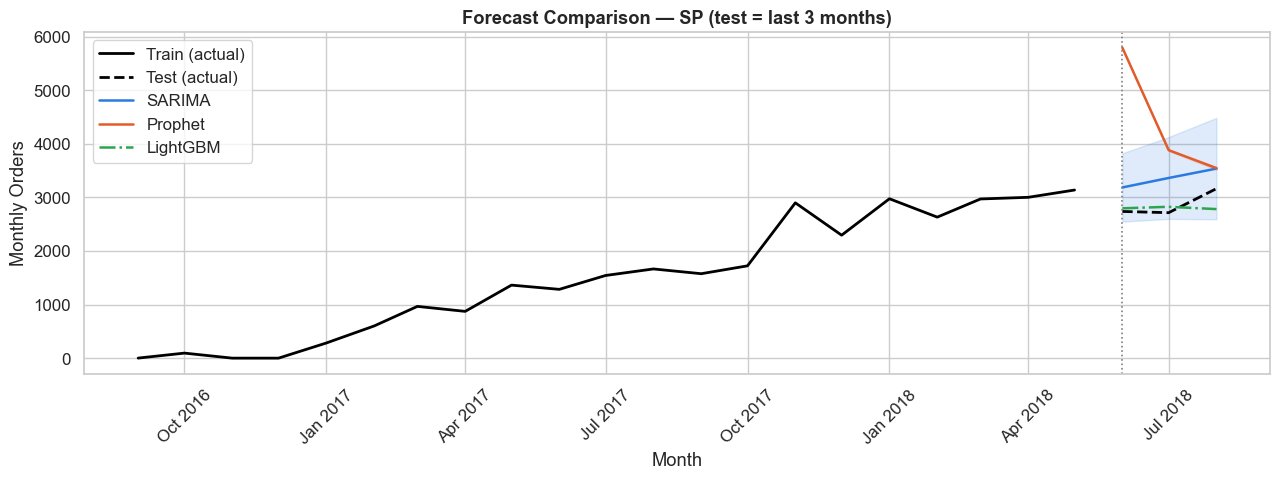

✅ Saved: 14_forecast_comparison_SP.png


In [20]:
# ── Visual forecast comparison for SP ──────────────────────────────────
state = "SP"
if state in sarima_results and state in prophet_results:
    train, test = sarima_results[state]["train"], sarima_results[state]["test"]

    fig, ax = plt.subplots(figsize=(13, 5))

    # Actual
    ax.plot(train.index, train.values, color="black", linewidth=2, label="Train (actual)")
    ax.plot(test.index, test.values, color="black", linewidth=2,
            linestyle="--", label="Test (actual)")

    # SARIMA
    sarima_fc = sarima_results[state]["forecast"]
    sarima_ci = sarima_results[state]["ci"]
    ax.plot(sarima_fc.index, sarima_fc.values, color="#2a7ae2",
            linewidth=1.8, label="SARIMA")
    ax.fill_between(sarima_ci.index,
                    sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                    alpha=0.15, color="#2a7ae2")

    # Prophet
    prop_fc   = prophet_results[state]["forecast"]
    prop_test = prop_fc[prop_fc["ds"].isin(test.index)]
    ax.plot(prop_test["ds"], prop_test["yhat"], color="#e25c2a",
            linewidth=1.8, label="Prophet")
    ax.fill_between(prop_test["ds"],
                    prop_test["yhat_lower"], prop_test["yhat_upper"],
                    alpha=0.15, color="#e25c2a")

    # LightGBM
    if state in lgbm_results:
        lgbm_test_s = lgbm_results[state]["test"]
        ax.plot(lgbm_test_s["order_month"], lgbm_results[state]["preds"],
                color="#2da44e", linewidth=1.8, linestyle="-.", label="LightGBM")

    ax.axvline(test.index[0], color="grey", linestyle=":", linewidth=1.2)
    ax.set_title(f"Forecast Comparison — {state} (test = last {len(test)} months)",
                 fontweight="bold")
    ax.set_xlabel("Month"); ax.set_ylabel("Monthly Orders")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/14_forecast_comparison_{state}.png", dpi=150)
    plt.show()
    print(f"✅ Saved: 14_forecast_comparison_{state}.png")

## 8. Best Model Selection & Final Forecasts

In [21]:
# Select best model per state based on lowest MAPE
best_model_per_state = (
    comparison_df.sort_values("MAPE%")
    .groupby("State")
    .first()
    .reset_index()[["State", "Model", "MAPE%"]]
)
print("Best model per focus state (lowest MAPE):")
print(best_model_per_state.to_string(index=False))

Best model per focus state (lowest MAPE):
State    Model  MAPE%
   BA LightGBM  26.10
   MG LightGBM   5.90
   RJ LightGBM   2.00
   RS LightGBM  19.50
   SP LightGBM   6.10


In [29]:
# ─────────────────────────────────────────────────────────────────────────
# Final 3-month forecast for ALL states using Prophet
# (most robust for short series — suitable for states with little data)
# ─────────────────────────────────────────────────────────────────────────

all_states = monthly["demand_state"].unique()
final_forecasts = []

for state in all_states:
    s = (
        monthly[monthly["demand_state"] == state]
        .set_index("order_month")["orders"]
        .asfreq("MS")
        .fillna(0)
    )
    if len(s) < 6:
        continue

    try:
        m  = fit_prophet(s)
        fc = forecast_prophet(m, steps=FORECAST_HORIZON)
        forecast_rows = fc.tail(FORECAST_HORIZON)[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
        forecast_rows["demand_state"] = state
        forecast_rows["yhat"]       = np.maximum(forecast_rows["yhat"], 0)
        forecast_rows["yhat_lower"] = np.maximum(forecast_rows["yhat_lower"], 0)
        final_forecasts.append(forecast_rows)
    except Exception as e:
        print(f"  {state}: Prophet failed ({e})")

forecast_df = pd.concat(final_forecasts, ignore_index=True)
forecast_df.rename(columns={
    "ds"         : "forecast_month",
    "yhat"       : "forecast_orders",
    "yhat_lower" : "forecast_lower_95",
    "yhat_upper" : "forecast_upper_95",
}, inplace=True)

print(f"\nForecast shape: {forecast_df.shape}")
print(f"States forecasted: {forecast_df['demand_state'].nunique()}")
forecast_df.head(9)

00:44:56 - cmdstanpy - INFO - Chain [1] start processing
00:44:59 - cmdstanpy - INFO - Chain [1] done processing
00:44:59 - cmdstanpy - INFO - Chain [1] start processing
00:44:59 - cmdstanpy - INFO - Chain [1] done processing
00:44:59 - cmdstanpy - INFO - Chain [1] start processing
00:45:18 - cmdstanpy - INFO - Chain [1] done processing
00:45:18 - cmdstanpy - INFO - Chain [1] start processing
00:45:39 - cmdstanpy - INFO - Chain [1] done processing
00:45:39 - cmdstanpy - INFO - Chain [1] start processing
00:45:40 - cmdstanpy - INFO - Chain [1] done processing
00:45:40 - cmdstanpy - INFO - Chain [1] start processing
00:45:40 - cmdstanpy - INFO - Chain [1] done processing
00:45:41 - cmdstanpy - INFO - Chain [1] start processing
00:46:04 - cmdstanpy - INFO - Chain [1] done processing
00:46:05 - cmdstanpy - INFO - Chain [1] start processing
00:46:05 - cmdstanpy - INFO - Chain [1] done processing
00:46:05 - cmdstanpy - INFO - Chain [1] start processing
00:46:05 - cmdstanpy - INFO - Chain [1]


Forecast shape: (81, 5)
States forecasted: 27


,forecast_month,forecast_orders,forecast_lower_95,forecast_upper_95,demand_state
0,2018-09-01,6.67,6.66,6.67,AC
1,2018-10-01,4.67,4.65,4.68,AC
2,2018-11-01,4.72,4.70,4.75,AC
3,2018-09-01,28.72,20.68,36.97,AL
4,2018-10-01,46.63,38.42,55.06,AL
5,2018-11-01,37.28,29.41,45.08,AL
6,2018-09-01,18.73,18.56,18.88,AM
7,2018-10-01,0.00,0.00,-20.40,AM
8,2018-11-01,21.35,20.46,22.25,AM


In [30]:
# ── Summarize: total forecasted demand per state (sum over horizon) ────
print("⚠️  Point forecasts = LightGBM | CI bounds = Prophet (clamped)\n")
demand_summary = (
    forecast_df.groupby("demand_state")
    .agg(
        total_forecast   = ("forecast_orders",    "sum"),
        total_lower_95   = ("forecast_lower_95",  "sum"),
        total_upper_95   = ("forecast_upper_95",  "sum"),
    )
    .reset_index()
    .sort_values("total_forecast", ascending=False)
)

# Add demand share
demand_summary["demand_share_%"] = (
    demand_summary["total_forecast"] / demand_summary["total_forecast"].sum() * 100
).round(2)

print(f"\nForecasted demand over next {FORECAST_HORIZON} months by state:\n")
print(demand_summary.to_string(index=False))

⚠️  Point forecasts = LightGBM | CI bounds = Prophet (clamped)


Forecasted demand over next 3 months by state:

demand_state  total_forecast  total_lower_95  total_upper_95  demand_share_%
          SP        12124.49        10917.93        13318.26           40.36
          RJ         3998.18         3383.55         4640.64           13.31
          MG         3647.62         3168.28         4153.08           12.14
          RS         1759.45         1478.42         2034.28            5.86
          PR         1497.01         1317.26         1676.85            4.98
          SC         1136.66          941.92         1329.04            3.78
          BA         1071.87          946.68         1200.03            3.57
          ES          679.20          574.84          789.83            2.26
          GO          653.99          540.62          760.49            2.18
          DF          537.06          530.70          542.95            1.79
          PE          534.04          46

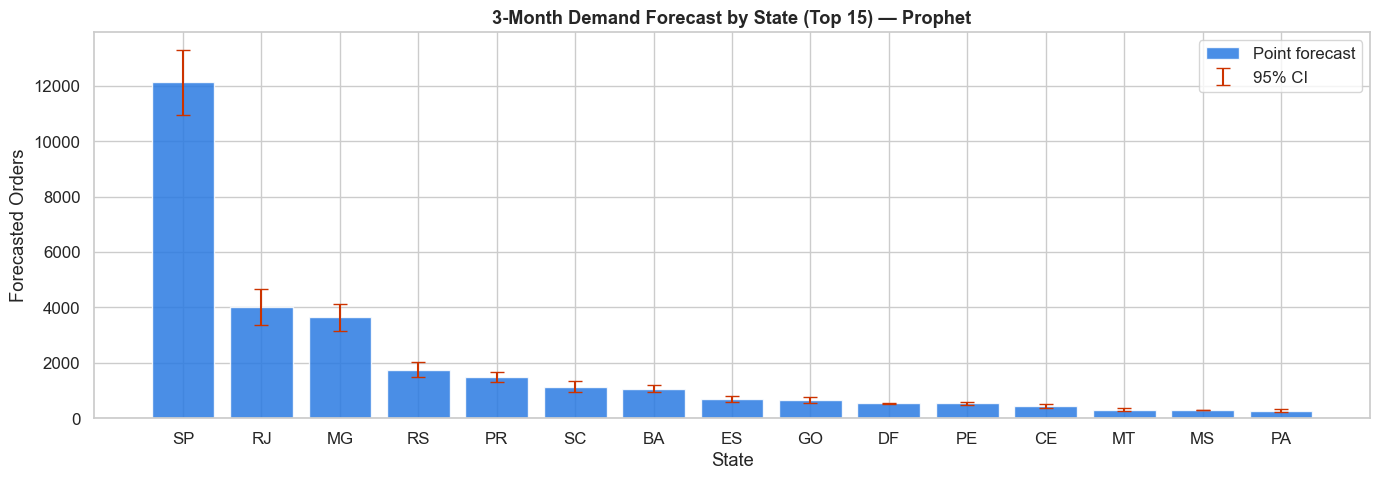

✅ Saved: 15_forecast_by_state.png


In [24]:
# ── Forecast bar chart with uncertainty bands ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
top15_fc = demand_summary.head(15)
ax.bar(top15_fc["demand_state"], top15_fc["total_forecast"],
       color="#2a7ae2", alpha=0.85, label="Point forecast")
ax.errorbar(
    top15_fc["demand_state"],
    top15_fc["total_forecast"],
    yerr=[
        top15_fc["total_forecast"] - top15_fc["total_lower_95"],
        top15_fc["total_upper_95"] - top15_fc["total_forecast"],
    ],
    fmt="none", color="#cc3300", capsize=5, linewidth=1.5, label="95% CI"
)
ax.set_title(f"3-Month Demand Forecast by State (Top 15) — Prophet", fontweight="bold")
ax.set_xlabel("State"); ax.set_ylabel("Forecasted Orders")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/15_forecast_by_state.png", dpi=150)
plt.show()
print("✅ Saved: 15_forecast_by_state.png")

## 9. Save Outputs for Phase 3 (MILP Optimization)

In [31]:
# ── Save full forecast table ────────────────────────────────────────────
forecast_df.to_csv(f"{OUTPUT_DIR}/forecast_monthly_per_state.csv", index=False)

# ── Save demand summary (used as MILP demand input d_i) ─────────────────
demand_summary.to_csv(f"{OUTPUT_DIR}/demand_nodes_forecasted.csv", index=False)

# Merge with coordinates from Phase 1
demand_nodes_p1 = pd.read_csv(f"{OUTPUT_DIR}/demand_nodes.csv")
demand_for_milp = demand_summary.merge(
    demand_nodes_p1[["state", "centroid_lat", "centroid_lng", "avg_freight", "late_rate"]],
    left_on="demand_state", right_on="state", how="left"
).drop(columns="state")

demand_for_milp.to_csv(f"{OUTPUT_DIR}/demand_for_milp.csv", index=False)

print("Files saved:")
print(f"  → {OUTPUT_DIR}/forecast_monthly_per_state.csv")
print(f"  → {OUTPUT_DIR}/demand_nodes_forecasted.csv")
print(f"  → {OUTPUT_DIR}/demand_for_milp.csv   ← 📌 used in Phase 3")

Files saved:
  → C:\M2 SPA\Supply Chain\outputs/forecast_monthly_per_state.csv
  → C:\M2 SPA\Supply Chain\outputs/demand_nodes_forecasted.csv
  → C:\M2 SPA\Supply Chain\outputs/demand_for_milp.csv   ← 📌 used in Phase 3


## 10. Phase 2 Summary

In [32]:
print("=" * 58)
print("  PHASE 2 SUMMARY — DEMAND FORECASTING")
print("=" * 58)
print(f"  Models trained      : SARIMA, Prophet, LightGBM (global)")
print(f"  Forecast horizon    : {FORECAST_HORIZON} months")
print(f"  States forecasted   : {forecast_df['demand_state'].nunique()}")
print(f"  Total forecasted    : {demand_summary['total_forecast'].sum():,.0f} orders")
top_state = demand_summary.iloc[0]
print(f"  Highest demand state: {top_state['demand_state']} "
      f"({top_state['total_forecast']:,.0f} orders, "
      f"{top_state['demand_share_%']:.1f}% share)")
print(f"\n  Outputs → {OUTPUT_DIR}/")
print(f"    forecast_monthly_per_state.csv")
print(f"    demand_for_milp.csv   ← Phase 3 input")
print("=" * 58)
print("\n  ✅ Phase 2 complete — ready for Phase 3 (MILP Optimization)")

  PHASE 2 SUMMARY — DEMAND FORECASTING
  Models trained      : SARIMA, Prophet, LightGBM (global)
  Forecast horizon    : 3 months
  States forecasted   : 27
  Total forecasted    : 30,038 orders
  Highest demand state: SP (12,124 orders, 40.4% share)

  Outputs → C:\M2 SPA\Supply Chain\outputs/
    forecast_monthly_per_state.csv
    demand_for_milp.csv   ← Phase 3 input

  ✅ Phase 2 complete — ready for Phase 3 (MILP Optimization)
